# 03 · Phase-space diagram of A2199 with the caustics

Projected radius vs. line-of-sight velocity of galaxies with a redshift, overlaid with the caustic envelope from `DATA/A2199/10_membership.py` (CausticSNUpy). Members are split into red-sequence and blue populations.

**Inputs**
- `DATA/AllHeCS_VAC_updated.csv` – HeCS-omnibus cluster catalog
- `DATA/A2199/A2199_mastercat_within35arcmin.csv` – A2199 master catalog
- `DATA/A2199/A2199_caustics.csv` – caustic envelope A(r) from the membership run

**Output**: figure only (`A2199_caustic` in the paper)

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "bold",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

## Load the catalog and correct for Galactic extinction

In [2]:
# Cluster redshift from the HeCS-omnibus cluster table
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'A2199']['Z'].values[0]

# A2199 master catalog (all SDSS objects within 35 arcmin of the cluster centre)
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

# Galactic-extinction-corrected model and Petrosian magnitudes (suffix "_0")
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_modelmag_{band}_0'] = df0[f'p_modelmag_{band}'] - df0[f'p_extinction_{band}']
for band in ['u', 'g', 'r', 'i', 'z']:
    df0[f'p_petromag_{band}_0'] = df0[f'p_petromag_{band}'] - df0[f'p_extinction_{band}']

# Galaxies only, within 35 arcmin
df = df0[(df0['galaxyflag'] == 1) & (df0['p_radgal'] < 35)].copy()

## Red and blue member populations

1. Fit the red sequence (g − r vs. r) to bright (r < 18), red (g − r > 0.5) spectroscopic members within 30′, as in notebook 01.
2. Compute the colour residual of every galaxy from the fit.
3. Members more than 3σ below the red sequence are **blue**; all other members are **red**. Non-members are labelled `none`.
4. Compute the projected distance of every galaxy from the caustic centre (the centre found by CausticSNUpy, which differs slightly from the HeCS centre).

In [3]:
from sklearn.linear_model import LinearRegression

# 1. Red-sequence fitting sample: bright, red spectroscopic members in the core
bright_members = df[
    (df['member'] == 'Y') &
    (df['p_radgal'] <= 30) &
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &
    (df['p_petromag_r_0'] < 18)
].copy()

# 2. Linear fit of (g - r) vs. r and its scatter
X = bright_members[['p_petromag_r_0']]
y = bright_members['p_modelmag_g_0'] - bright_members['p_modelmag_r_0']
model = LinearRegression().fit(X, y)
slope, intercept = model.coef_[0], model.intercept_
sigma = np.std(y - model.predict(X))

# 3. Colour residual from the red sequence for the whole sample
df['g_r'] = df['p_modelmag_g_0'] - df['p_modelmag_r_0']
df['g_r_pred'] = model.predict(df[['p_petromag_r_0']])
df['residual'] = df['g_r'] - df['g_r_pred']

# 4. Population labels: blue = member more than 3 sigma below the red sequence
df['population'] = 'none'
blue = (df['member'] == 'Y') & (df['residual'] < -3 * sigma)
red = (df['member'] == 'Y') & (df['residual'] >= -3 * sigma)
df.loc[blue, 'population'] = 'blue'
df.loc[red, 'population'] = 'red'


def angular_distance(ra1, dec1, ra2, dec2):
    """Angular separation between two sky positions (degrees in, arcmin out)."""
    coord1 = SkyCoord(ra=ra1 * u.deg, dec=dec1 * u.deg)
    coord2 = SkyCoord(ra=ra2 * u.deg, dec=dec2 * u.deg)
    return coord1.separation(coord2).arcminute


# 5. Caustic centre and redshift as found by CausticSNUpy (10_membership.py)
TARGET = 'A2199'
ra_caustic  = 247.12260   # deg
dec_caustic = 39.53099    # deg
z_caustic   = 0.030198

df['p_radgal_caustic'] = df.apply(
    lambda row: angular_distance(row['p_ra'], row['p_dec'], ra_caustic, dec_caustic),
    axis=1
)

## Phase-space diagram

- Middle panel: cluster-centric velocity cΔz/(1 + z_cl) vs. projected radius, with the caustic envelope (black). Red circles / blue crosses: red / blue members; small black dots: non-members.
- Top: radial distribution of red and blue members. Right of the middle panel: velocity histograms.
- Bottom: r-band magnitude vs. radius, with the magnitude histogram of all galaxies (black) and members (purple) on the right.

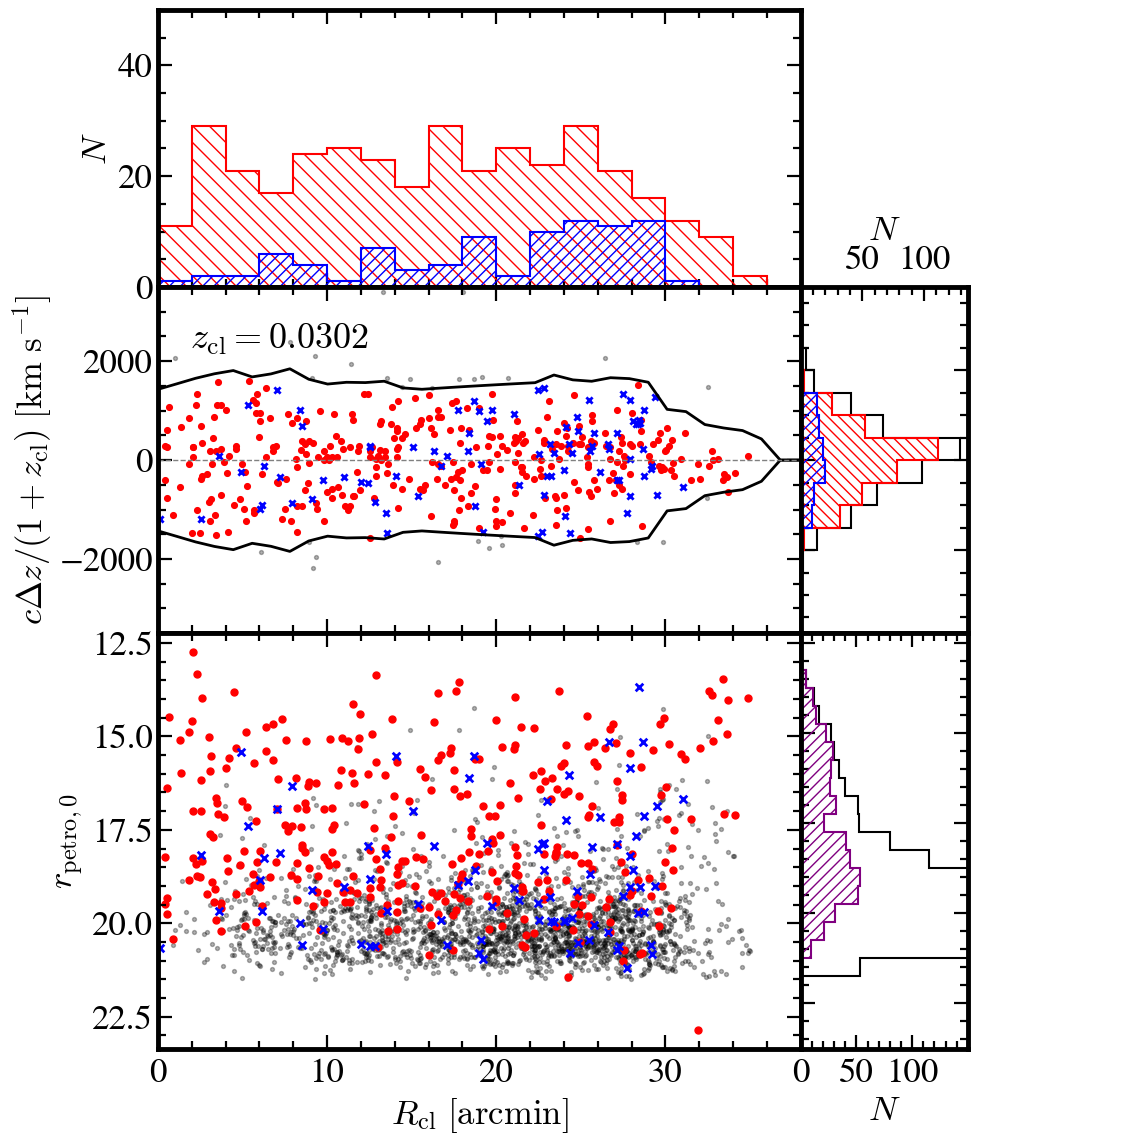

In [4]:
# Caustic envelope A(r) from 10_membership.py (r in arcmin, A in km/s)
caustic_df = pd.read_csv('../../DATA/A2199/A2199_caustics.csv')

c = 299792.458      # speed of light, km/s

# Galaxies with a redshift within 35 arcmin of the caustic centre
df_plot = df[(df['z_tot_z'] != -9) & (df['p_radgal_caustic'] < 35)].copy()

# Cluster-centric velocity. Note: this must use the same centre and the same
# z -> velocity convention as the CausticSNUpy run that produced A2199_caustics.csv;
# otherwise the galaxies and the envelope are offset from each other.
df_plot['delta_v'] = c * (df_plot['z_tot_z'] - z_caustic) / (1 + z_caustic)

mask_none   = df_plot['population'].isna() | (df_plot['population'] == 'none')
mask_red    = df_plot['population'] == 'red'
mask_blue   = df_plot['population'] == 'blue'
mask_member = df_plot['member'] == 'Y'

# Histogram bins
x_bin_width   = 2       # arcmin
vel_bin_width = 500     # km/s
mag_bin_width = 0.5     # mag

x_bins = np.arange(0, 35 + x_bin_width, x_bin_width)
vel_bins = np.arange(-3500, 3500 + vel_bin_width, vel_bin_width)
mag_bins = np.arange(
    df_plot['p_petromag_r_0'].min(),
    df_plot['p_petromag_r_0'].max() + mag_bin_width,
    mag_bin_width
)

# ---- Figure layout ----
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 3,
    width_ratios=[5, 1.3, 1.3],
    height_ratios=[1.2, 1.5, 1.8],
    hspace=0.0, wspace=0.0
)

ax_top_hist  = fig.add_subplot(gs[0, 0])
ax_vel_panel = fig.add_subplot(gs[1, 0])
ax_mag_panel = fig.add_subplot(gs[2, 0])
ax_vel_rhist = fig.add_subplot(gs[1, 1])
ax_mag_rhist = fig.add_subplot(gs[2, 1])
ax_blank     = fig.add_subplot(gs[0, 1])
ax_blank.axis('off')
for i in range(3):
    fig.add_subplot(gs[i, 2]).axis('off')

# ---- Top: radial distribution of red / blue members ----
ax_top_hist.hist(df_plot.loc[mask_red, 'p_radgal_caustic'], bins=x_bins,
                 histtype='step', facecolor='none', edgecolor='red', hatch='\\\\', linewidth=1.5)
ax_top_hist.hist(df_plot.loc[mask_blue, 'p_radgal_caustic'], bins=x_bins,
                 histtype='step', facecolor='none', edgecolor='blue', hatch='///', linewidth=1.5)
ax_top_hist.set_ylabel(r'$N$')
ax_top_hist.set_xlim(0, 38)
ax_top_hist.set_ylim(0, 50)
ax_top_hist.tick_params(which='both', direction='in', right=True, labelbottom=False)
ax_top_hist.minorticks_on()

# ---- Middle: velocity vs. radius with the caustics ----
ax_vel_panel.scatter(df_plot.loc[mask_none, 'p_radgal_caustic'], df_plot.loc[mask_none, 'delta_v'],
                     s=8, color='black', alpha=0.3, marker='o')
ax_vel_panel.scatter(df_plot.loc[mask_red, 'p_radgal_caustic'], df_plot.loc[mask_red, 'delta_v'],
                     s=17, color='red', marker='o')
ax_vel_panel.scatter(df_plot.loc[mask_blue, 'p_radgal_caustic'], df_plot.loc[mask_blue, 'delta_v'],
                     s=20, color='blue', marker='x', linewidths=2)

ax_vel_panel.plot(caustic_df['r_arcmin'], caustic_df['A_upper'], color='black', linewidth=2)
ax_vel_panel.plot(caustic_df['r_arcmin'], caustic_df['A_lower'], color='black', linewidth=2)

ax_vel_panel.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_vel_panel.set_ylabel(r'$c\Delta z / (1 + z_\mathrm{cl})\ [\mathrm{km\ s^{-1}}]$')
ax_vel_panel.set_ylim(-3500, 3500)
ax_vel_panel.set_xlim(0, 38)
ax_vel_panel.tick_params(which='both', direction='in', top=True, right=True)
ax_vel_panel.minorticks_on()
ax_vel_panel.set_xticklabels([])
ax_vel_panel.annotate(rf'$z_\mathrm{{cl}} = {z_caustic:.4f}$', xy=(0.05, 0.90), xycoords='axes fraction',
                      ha='left', va='top', fontsize=26)

# ---- Right of middle: velocity histograms ----
ax_vel_rhist.hist(df_plot['delta_v'], bins=vel_bins, orientation='horizontal', histtype='step',
                  color='black', linewidth=1.5)
ax_vel_rhist.hist(df_plot.loc[mask_red, 'delta_v'], bins=vel_bins, orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='red', hatch='\\\\\\', linewidth=1.5)
ax_vel_rhist.hist(df_plot.loc[mask_blue, 'delta_v'], bins=vel_bins, orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='blue', hatch='///', linewidth=1.5)
ax_vel_rhist.set_xlabel(r'$N$')
ax_vel_rhist.xaxis.set_label_position('top')
ax_vel_rhist.xaxis.tick_top()
ax_vel_rhist.tick_params(which='both', direction='in', labelleft=False)
ax_vel_rhist.minorticks_on()
ax_vel_rhist.set_xticks([50, 100])

# ---- Bottom: magnitude vs. radius ----
ax_mag_panel.scatter(df_plot.loc[mask_none, 'p_radgal_caustic'], df_plot.loc[mask_none, 'p_petromag_r_0'],
                     s=8, color='black', alpha=0.3, marker='o')
ax_mag_panel.scatter(df_plot.loc[mask_red, 'p_radgal_caustic'], df_plot.loc[mask_red, 'p_petromag_r_0'],
                     s=25, color='red', marker='o')
ax_mag_panel.scatter(df_plot.loc[mask_blue, 'p_radgal_caustic'], df_plot.loc[mask_blue, 'p_petromag_r_0'],
                     s=30, color='blue', marker='x', linewidths=2)
ax_mag_panel.set_ylabel(r'$r_\mathrm{petro,0}$')
ax_mag_panel.set_xlabel(r'$R_\mathrm{cl}\ [\mathrm{arcmin}]$')
ax_mag_panel.invert_yaxis()
ax_mag_panel.set_xlim(0, 38)
ax_mag_panel.tick_params(which='both', direction='in', top=True, right=True)
ax_mag_panel.minorticks_on()

# ---- Right of bottom: magnitude histograms (all / members) ----
ax_mag_rhist.hist(df_plot['p_petromag_r_0'], bins=mag_bins, orientation='horizontal', histtype='step',
                  color='black', linewidth=1.5)
ax_mag_rhist.hist(df_plot.loc[mask_member, 'p_petromag_r_0'], bins=mag_bins, orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='purple', hatch='///', linewidth=1.5)
ax_mag_rhist.set_xlabel(r'$N$')
ax_mag_rhist.invert_yaxis()
ax_mag_rhist.tick_params(which='both', direction='in', top=True, labelleft=False)
ax_mag_rhist.minorticks_on()
ax_mag_rhist.set_xticks([0, 50, 100])
ax_mag_rhist.set_xlim(0, 150)

plt.setp(ax_top_hist.get_xticklabels(), visible=False)
plt.setp(ax_vel_rhist.get_yticklabels(), visible=False)
plt.setp(ax_mag_rhist.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()